# Zero-DCE++ with SE-Block — clean rebuild (v7)

## Why this exists
v5/v6 added DPED-style hybrid losses and a channel-balance term on top of the
**original Zero-DCE** architecture (standard convolutions). That direction is
dropped entirely here — no hybrid losses, no channel-balance term, back to the
plain four-component zero-reference loss.

More importantly, this rebuild also fixes an architecture mismatch: v1\u2013v6 all
used **standard convolutions** with a 24-channel (8\u00d73 RGB) curve map — that is
actually the **original Zero-DCE** (Guo et al., 2020) backbone, not Zero-DCE++'s.
Zero-DCE++'s defining trait (Li et al., 2022) is **depth-separable convolutions**
with a single shared 3-channel curve reused across all 8 iterations, which is what
this notebook implements, ported to PyTorch from a tested TensorFlow reference
implementation (`zero_dce_lite.py` / `losses.py`).

**If you keep this version, note for BAB II/III:** the 24-channel description in
section 2.2.2 (and Rumus 2.1) describes the ORIGINAL Zero-DCE's per-iteration
curves, not this architecture's single shared 3-channel curve (Rumus 2.1 changes
accordingly — see the architecture cell below). That section will need updating
to stay accurate to what's actually implemented.


### 1. Imports

In [1]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torchvision.transforms.functional as TF
from PIL import Image
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm import tqdm
import cv2
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
torch.manual_seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

Device: cuda
GPU: NVIDIA GeForce RTX 3060


### 2. SE-Block

Unchanged from v4/v5 — this is the actual thesis contribution and doesn't depend
on which convolution type surrounds it.

In [2]:
class SEBlock(nn.Module):
    def __init__(self, channels, reduction=4): #reduced from 8 to 4 to increase the number of parameters and improve performance
        super().__init__()
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(channels, channels // reduction, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(channels // reduction, channels, bias=False),
            nn.Sigmoid()
        )
    def forward(self, x):
        b, c, _, _ = x.shape
        w = self.pool(x).view(b, c)
        w = self.fc(w).view(b, c, 1, 1)
        return x * w

print('SE-Block defined')

SE-Block defined


### 3. Depth-Separable Convolution + DCE-Net++

`DepthSeparableConv2d` factors a standard conv into a per-channel spatial filter
(depthwise) followed by a 1\u00d71 channel-mixing filter (pointwise) — this is the
actual mechanism that cuts Zero-DCE++'s parameter count vs. the original.

`DCENetLite` mirrors the reference repo's `zero_dce_lite.py` exactly: same 7-layer
skip-connection topology, but the output layer produces only **3 channels**
(not 24) — a single curve map, reused iteratively 8 times, rather than 8 distinct
per-iteration curves. SE-Block is inserted after Conv3, matching the thesis's
chosen placement (C=32, r=8, bottleneck=4).

In [4]:
class DepthSeparableConv2d(nn.Module):
    """Depthwise conv (per-channel spatial filter) + pointwise 1x1 (channel mixing).
    Matches TF's SeparableConv2D: depth_multiplier=1, RandomNormal(std=0.02) init."""
    def __init__(self, in_channels, out_channels, kernel_size=3, stride=1, padding=1):
        super().__init__()
        self.depthwise = nn.Conv2d(in_channels, in_channels, kernel_size, stride, padding,
                                    groups=in_channels, bias=True)
        self.pointwise = nn.Conv2d(in_channels, out_channels, kernel_size=1, bias=True)
        nn.init.normal_(self.depthwise.weight, mean=0.0, std=0.02)
        nn.init.normal_(self.pointwise.weight, mean=0.0, std=0.02)
        nn.init.zeros_(self.depthwise.bias)
        nn.init.zeros_(self.pointwise.bias)

    def forward(self, x):
        return self.pointwise(self.depthwise(x))


class DCENetLite(nn.Module):
    """Zero-DCE++ backbone: depth-separable convs, SE-Block after Conv3,
    single shared 3-channel curve map (not per-iteration 24-channel)."""
    def __init__(self, filters=32, use_attention=True, iterations=8):
        super().__init__()
        self.use_attention = use_attention
        self.iterations    = iterations

        self.conv1 = DepthSeparableConv2d(3,          filters)
        self.conv2 = DepthSeparableConv2d(filters,    filters)
        self.conv3 = DepthSeparableConv2d(filters,    filters)
        if use_attention:
            self.se = SEBlock(filters, reduction=4)  # reduced from 8 to 4 to increase the number of parameters and improve performance
        self.conv4 = DepthSeparableConv2d(filters,    filters)
        self.conv5 = DepthSeparableConv2d(filters*2,  filters)  # concat(x3, x4)
        self.conv6 = DepthSeparableConv2d(filters*2,  filters)  # concat(x2, x5)
        self.conv7 = DepthSeparableConv2d(filters*2,  3)        # concat(x1, x6) -> 3ch only
        self.relu  = nn.ReLU(inplace=True)

    def forward(self, x):
        x1 = self.relu(self.conv1(x))
        x2 = self.relu(self.conv2(x1))
        x3 = self.relu(self.conv3(x2))
        if self.use_attention:
            x3 = self.se(x3)
        x4 = self.relu(self.conv4(x3))
        x5 = self.relu(self.conv5(torch.cat([x3, x4], 1)))
        x6 = self.relu(self.conv6(torch.cat([x2, x5], 1)))
        a_map = torch.tanh(self.conv7(torch.cat([x1, x6], 1)))  # [B, 3, H, W]
        return a_map


def enhance_image_with_curve(x, a_map, iterations=8):
    """Same curve applied `iterations` times, matching the reference repo exactly:
    enhanced = enhanced + a * (enhanced^2 - enhanced)
    This is algebraically -a * enhanced * (1 - enhanced) -- the same LE() family
    from the paper, just with alpha's sign convention flipped. Since alpha is
    learned freely (tanh output, both signs available), this is not a functional
    difference, only a labeling one."""
    enhanced = x
    for _ in range(iterations):
        enhanced = enhanced + a_map * (enhanced.pow(2) - enhanced)
    return torch.clamp(enhanced, 0, 1)


model = DCENetLite(use_attention=True).to(device)
print(f'Model: {sum(p.numel() for p in model.parameters()):,} parameters')

Model: 11,073 parameters


### 4. Loss Functions (ported from tested TF reference)

Direct ports of `losses.py` — same math, PyTorch tensor layout (`[B,C,H,W]`
instead of TF's `[B,H,W,C]`). Weights below match the reference repo's **lite**
defaults (`zero_dce_lite.py`'s `compile()`), which are tuned for this
depth-separable architecture specifically — notably different from the
standard-conv version's weights (1, 20, 10, 400) used in v1\u2013v6.

One faithfulness note on `ColorConstancyLoss`: the reference squares each
per-pair channel difference and then squares again inside the sqrt
(`sqrt(Drg\u00b2 + Drb\u00b2 + Dbg\u00b2)` where `Drg` is already `(mr-mg)\u00b2`). That's
ported exactly as written, since the ask was fidelity to the tested reference —
worth knowing if you ever want to compare against the more common single-square
version of this loss.

In [5]:
class SpatialConsistencyLoss(nn.Module):
    def __init__(self):
        super().__init__()
        k_left  = torch.tensor([[0.,0.,0.],[-1.,1.,0.],[0.,0.,0.]]).view(1,1,3,3)
        k_right = torch.tensor([[0.,0.,0.],[0.,1.,-1.],[0.,0.,0.]]).view(1,1,3,3)
        k_up    = torch.tensor([[0.,-1.,0.],[0.,1.,0.],[0.,0.,0.]]).view(1,1,3,3)
        k_down  = torch.tensor([[0.,0.,0.],[0.,1.,0.],[0.,-1.,0.]]).view(1,1,3,3)
        self.register_buffer('k_left',  k_left)
        self.register_buffer('k_right', k_right)
        self.register_buffer('k_up',    k_up)
        self.register_buffer('k_down',  k_down)
        self.pool = nn.AvgPool2d(kernel_size=4, stride=4)

    def forward(self, inp, enh):
        inp_mean = inp.mean(dim=1, keepdim=True)
        enh_mean = enh.mean(dim=1, keepdim=True)
        inp_pool = self.pool(inp_mean)
        enh_pool = self.pool(enh_mean)

        d_inp = [F.conv2d(inp_pool, k, padding=1) for k in
                 (self.k_left, self.k_right, self.k_up, self.k_down)]
        d_enh = [F.conv2d(enh_pool, k, padding=1) for k in
                 (self.k_left, self.k_right, self.k_up, self.k_down)]

        return sum((di - de).pow(2) for di, de in zip(d_inp, d_enh)).mean()


class ExposureControlLoss(nn.Module):
    def __init__(self, e=0.6, patch_size=16):
        super().__init__()
        self.e = e
        self.pool = nn.AvgPool2d(kernel_size=patch_size, stride=patch_size)

    def forward(self, enhanced):
        mean_c = enhanced.mean(dim=1, keepdim=True)
        pooled = self.pool(mean_c)
        return (pooled - self.e).pow(2).mean()


class ColorConstancyLoss(nn.Module):
    def forward(self, enhanced):
        mean_rgb = enhanced.mean(dim=[2, 3], keepdim=True)  # [B, 3, 1, 1]
        mr, mg, mb = mean_rgb[:, 0:1], mean_rgb[:, 1:2], mean_rgb[:, 2:3]
        d_rg = (mr - mg).pow(2)
        d_rb = (mr - mb).pow(2)
        d_gb = (mb - mg).pow(2)
        # return torch.sqrt(d_rg.pow(2) + d_rb.pow(2) + d_gb.pow(2)).mean()
        return torch.sqrt(d_rg + d_rb + d_gb + 1e-8).mean() # change to original paper


class IlluminationSmoothnessLoss(nn.Module):
    """NOTE: normalization constants (count_h, count_w) are ported literally from
    the TF reference, which indexes shape[2]/shape[3] (W and C) rather than H/W --
    this looks like an inherited indexing quirk in the source repo, not something
    introduced here. It doesn't break training (it's just a scalar that interacts
    with the loss weight below), but flagging it in case you want the 'textbook'
    (H-1)*W*C / H*(W-1)*C normalization instead."""
    def forward(self, alpha_map):
        b, c, h, w = alpha_map.shape
        count_h = (w - 1) * c
        count_w = w * (c - 1)

        tv_h = (alpha_map[:, :, 1:, :] - alpha_map[:, :, :h-1, :]).pow(2).sum() / count_h
        tv_w = (alpha_map[:, :, :, 1:] - alpha_map[:, :, :, :w-1]).pow(2).sum() / count_w

        return 2 * (tv_h + tv_w) / b


class ZeroDCELoss(nn.Module):
    """Combines all four terms with the reference repo's LITE weights."""
    def __init__(self, e=0.52, patch_size=16, # changing e from 0.6 to 0.52 to match the dataset mean brightness
                 w_spa=5.0, w_exp=20.0, w_col=5.0, w_ill=400.0): # change from original weights (spa=1, exp=70, col=200, ill=1200) to lite weights (spa=5, exp=20, col=5, ill=400)
        super().__init__()
        self.spa = SpatialConsistencyLoss()
        self.exp = ExposureControlLoss(e=e, patch_size=patch_size)
        self.col = ColorConstancyLoss()
        self.ill = IlluminationSmoothnessLoss()
        self.w_spa, self.w_exp, self.w_col, self.w_ill = w_spa, w_exp, w_col, w_ill

    def forward(self, enhanced, input_img, a_map):
        l_spa = self.spa(input_img, enhanced)
        l_exp = self.exp(enhanced)
        l_col = self.col(enhanced)
        l_ill = self.ill(a_map)
        total = (self.w_spa * l_spa + self.w_exp * l_exp
                 + self.w_col * l_col + self.w_ill * l_ill)
        return total, l_spa, l_exp, l_col, l_ill

loss_fn = ZeroDCELoss().to(device)
print('Loss functions defined (lite weights: spa=1, exp=70, col=200, ill=1200)')

Loss functions defined (lite weights: spa=1, exp=70, col=200, ill=1200)


### 5. Dataset (LOL-v2 Real_captured, paired Low/Normal)

Unchanged from v4/v5 — `normal` is loaded for later PSNR/SSIM evaluation, not used in training (this architecture trains zero-reference, exactly like the original).

In [6]:
class LOLDataset(Dataset):
    def __init__(self, image_pairs, img_size=512, augment=False):
        self.image_pairs = image_pairs
        self.img_size    = img_size
        self.augment     = augment
        self.resize_size = int(img_size * 1.15)

    def __len__(self):
        return len(self.image_pairs)

    def __getitem__(self, idx):
        pair = self.image_pairs[idx]
        low_img    = Image.open(pair['low']).convert('RGB')
        normal_img = Image.open(pair['normal']).convert('RGB')

        # Resize by SHORT SIDE — preserves aspect ratio
        low_img    = TF.resize(low_img,    self.resize_size, interpolation=Image.BILINEAR)
        normal_img = TF.resize(normal_img, self.resize_size, interpolation=Image.BILINEAR)

        if self.augment:
            i, j, h, w = transforms.RandomCrop.get_params(
                low_img, (self.img_size, self.img_size))
            low_img    = TF.crop(low_img,    i, j, h, w)
            normal_img = TF.crop(normal_img, i, j, h, w)
            if torch.rand(1) > 0.5:
                low_img    = TF.hflip(low_img)
                normal_img = TF.hflip(normal_img)
        else:
            low_img    = TF.center_crop(low_img,    self.img_size)
            normal_img = TF.center_crop(normal_img, self.img_size)

        return {
            'low':      TF.to_tensor(low_img),
            'normal':   TF.to_tensor(normal_img),
            'filename': pair['filename']
        }

def load_image_pairs(data_path):
    low_p  = data_path / 'Low'
    norm_p = data_path / 'Normal'
    lows   = sorted([f for f in os.listdir(low_p)  if f.endswith(('.jpg','.png'))])
    norms  = sorted([f for f in os.listdir(norm_p) if f.endswith(('.jpg','.png'))])
    assert len(lows)==len(norms), f'Pair mismatch: {len(lows)} vs {len(norms)}'
    return [{'low':str(low_p/l),'normal':str(norm_p/n),'filename':l}
            for l,n in zip(lows,norms)]

BASE_PATH    = Path('LOL-v2')
train_pairs  = load_image_pairs(BASE_PATH / 'Real_captured' / 'Train')
test_pairs   = load_image_pairs(BASE_PATH / 'Real_captured' / 'Test')
print(f'LOL-v2: {len(train_pairs)} train, {len(test_pairs)} test')

BATCH_SIZE  = 8
IMG_SIZE    = 512
train_loader = DataLoader(LOLDataset(train_pairs, IMG_SIZE, augment=True),
                          batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
test_loader  = DataLoader(LOLDataset(test_pairs,  IMG_SIZE, augment=False),
                          batch_size=1,          shuffle=False, num_workers=0)
print(f'Train batches: {len(train_loader)} | Test batches: {len(test_loader)}')

LOL-v2: 689 train, 100 test
Train batches: 87 | Test batches: 100


### 6. Training

Pure zero-reference training, single optimizer — no hybrid losses, no discriminator. Same gradient accumulation / collapse guard / early stopping structure as before, since those were never part of the hybrid experiment and are still good practice.

In [8]:
LEARNING_RATE = 1e-4
WEIGHT_DECAY  = 1e-5 # reduce weight decay to prevent overfitting
NUM_EPOCHS    = 200
PATIENCE      = 35 # increased from 25 to 35 to allow more epochs for convergence before early stopping
ACCUM_STEPS   = 2 # change from 4 to 2 to reduce memory usage and allow larger effective batch size
CHECKPOINT    = 'best_zerodce_pp_seblock.pth'

optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS, eta_min=1e-7)

history = {'loss':[],'spa':[],'exp':[],'col':[],'ill':[],'lr':[]}
best_loss     = float('inf')
no_improve    = 0
stopped_epoch = NUM_EPOCHS

print(f"{'='*60}")
print(f'TRAINING Zero-DCE++ (depth-separable) + SE-Block \u2014 max {NUM_EPOCHS} epochs, patience={PATIENCE}')
print(f'Effective batch: {BATCH_SIZE}\u00d7{ACCUM_STEPS} = {BATCH_SIZE*ACCUM_STEPS}')
print(f"{'='*60}")

for epoch in range(NUM_EPOCHS):
    model.train()
    totals = dict(loss=0, spa=0, exp=0, col=0, ill=0)

    optimizer.zero_grad()
    pbar = tqdm(enumerate(train_loader), total=len(train_loader),
                desc=f'[{epoch+1}/{NUM_EPOCHS}]')

    for step, batch in pbar:
        low_imgs = batch['low'].to(device)

        a_map    = model(low_imgs)
        enhanced = enhance_image_with_curve(low_imgs, a_map)

        loss, l_spa, l_exp, l_col, l_ill = loss_fn(enhanced, low_imgs, a_map)

        (loss / ACCUM_STEPS).backward()

        if (step + 1) % ACCUM_STEPS == 0 or (step + 1) == len(train_loader):
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0) # change from 0.1 to 1.0 to allow larger gradient updates and improve convergence
            optimizer.step()
            optimizer.zero_grad()

        totals['loss'] += loss.item()
        totals['spa']  += l_spa.item()
        totals['exp']  += l_exp.item()
        totals['col']  += l_col.item()
        totals['ill']  += l_ill.item()
        pbar.set_postfix({'loss': f'{loss.item():.4f}', 'exp': f'{l_exp.item():.4f}'})

    n = len(train_loader)
    avg_loss = totals['loss'] / n
    for k in ['loss','spa','exp','col','ill']:
        history[k].append(totals[k] / n)
    history['lr'].append(optimizer.param_groups[0]['lr'])

    # Collapse guard: check mean brightness every 10 epochs \u2500\u2500\u2500\u2500\u2500
    if (epoch + 1) % 10 == 0:
        model.eval()
        with torch.no_grad():
            sample = next(iter(train_loader))['low'].to(device)
            a_s    = model(sample)
            e_s    = enhance_image_with_curve(sample, a_s)
            mean_brightness = e_s.mean().item()
        model.train()
        print(f'  [Epoch {epoch+1}] mean_brightness={mean_brightness:.4f}', end='')
        if mean_brightness < 0.1:
            print(' \u2014 COLLAPSE DETECTED, stopping!')
            stopped_epoch = epoch + 1
            break
        else:
            print(f' | no_improve={no_improve}/{PATIENCE}')

    # Early stopping
    if avg_loss < best_loss:
        best_loss  = avg_loss
        no_improve = 0
        torch.save(model.state_dict(), CHECKPOINT)
        print(f'  Epoch {epoch+1}: loss={avg_loss:.6f}  [BEST saved]')
    else:
        no_improve += 1
        if no_improve >= PATIENCE:
            stopped_epoch = epoch + 1
            print(f'  Early stopping at epoch {stopped_epoch}')
            break

    scheduler.step()

print(f"\n{'='*60}")
print(f'DONE \u2014 best loss: {best_loss:.6f} | stopped at epoch: {stopped_epoch}')
print(f"{'='*60}")

TRAINING Zero-DCE++ (depth-separable) + SE-Block — max 200 epochs, patience=35
Effective batch: 8×2 = 16


[1/200]: 100%|██████████| 87/87 [00:49<00:00,  1.77it/s, loss=4.4295, exp=0.2182]


  Epoch 1: loss=4.335022  [BEST saved]


[2/200]: 100%|██████████| 87/87 [00:41<00:00,  2.10it/s, loss=4.7248, exp=0.2252]


  Epoch 2: loss=4.256583  [BEST saved]


...

  [Epoch 40] mean_brightness=0.4112 | no_improve=16/35


[50/200]: 100%|██████████| 87/87 [00:40<00:00,  2.12it/s, loss=2.1450, exp=0.0807]


  [Epoch 50] mean_brightness=0.4456 | no_improve=26/35


[58/200]: 100%|██████████| 87/87 [00:41<00:00,  2.10it/s, loss=2.1164, exp=0.0892]

  Early stopping at epoch 58

DONE — best loss: 1.948840 | stopped at epoch: 58


### 7. Training Curves

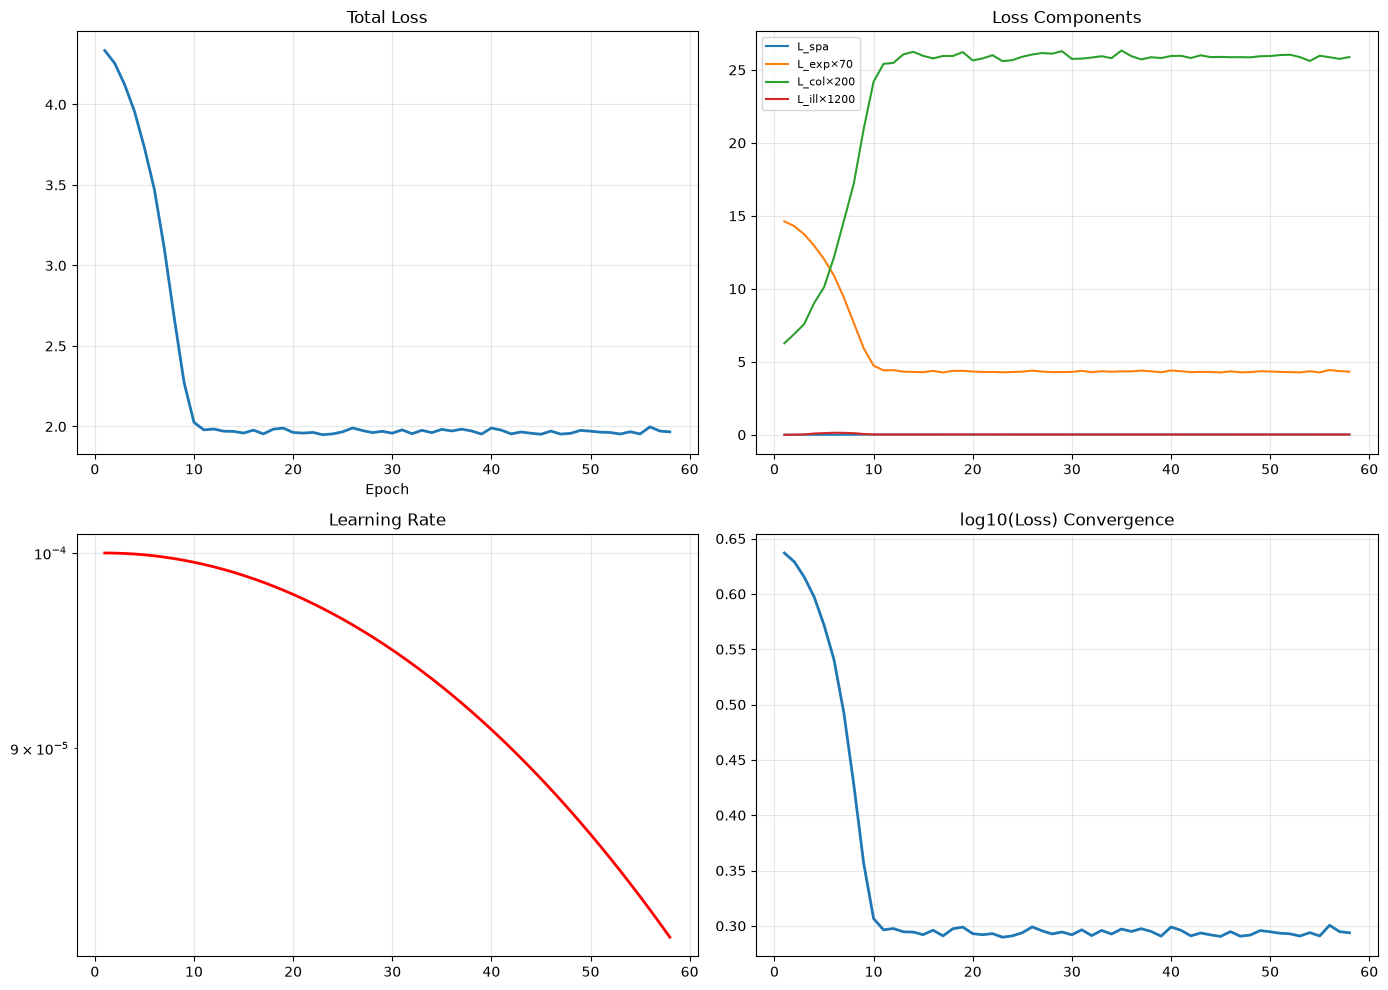

Saved: training_history_pp.png


In [9]:
ep = range(1, len(history['loss'])+1)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0,0].plot(ep, history['loss'], linewidth=2)
axes[0,0].set_title('Total Loss'); axes[0,0].set_xlabel('Epoch')
axes[0,0].grid(True, alpha=0.3)

axes[0,1].plot(ep, history['spa'],                    label='L_spa')
axes[0,1].plot(ep, np.array(history['exp'])*70,       label='L_exp\u00d770')
axes[0,1].plot(ep, np.array(history['col'])*200,      label='L_col\u00d7200')
axes[0,1].plot(ep, np.array(history['ill'])*1200,     label='L_ill\u00d71200')
axes[0,1].set_title('Loss Components')
axes[0,1].legend(fontsize=8); axes[0,1].grid(True, alpha=0.3)

axes[1,0].semilogy(ep, history['lr'], color='red', linewidth=2)
axes[1,0].set_title('Learning Rate'); axes[1,0].grid(True, alpha=0.3)

axes[1,1].plot(ep, np.log10(np.array(history['loss'])+1e-8), linewidth=2)
axes[1,1].set_title('log10(Loss) Convergence'); axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_history_pp.png', dpi=150)
plt.show()
print('Saved: training_history_pp.png')

### 8. Inference — bilateral filter for real-world photos

Same as before: denoising happens at inference only, not during training.

In [17]:
def enhance_single_image(image_path, checkpoint=CHECKPOINT,
                          denoise=True, d=9, sigma_color=75, sigma_space=75):
    m = DCENetLite(use_attention=True).to(device)
    m.load_state_dict(torch.load(checkpoint, map_location=device))
    m.eval()

    img = Image.open(image_path).convert('RGB')
    inp = TF.to_tensor(img).unsqueeze(0).to(device)

    with torch.no_grad():
        enh = enhance_image_with_curve(inp, m(inp))

    enh_np = (enh.squeeze(0).cpu().permute(1,2,0).numpy()*255).astype(np.uint8)

    if denoise:
        bgr    = cv2.cvtColor(enh_np, cv2.COLOR_RGB2BGR)
        bgr    = cv2.bilateralFilter(bgr, d=d, sigmaColor=sigma_color, sigmaSpace=sigma_space)
        enh_np = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    axes[0].imshow(np.array(img)); axes[0].set_title('Input (low-light)');  axes[0].axis('off')
    axes[1].imshow(enh_np);        axes[1].set_title('Enhanced (Zero-DCE++)' + (' + Bilateral' if denoise else ''))
    axes[1].axis('off')
    plt.tight_layout()
    plt.savefig('inference_pp.png', dpi=150)
    plt.show()
    return enh_np

print('Usage:')
print('  enhance_single_image("your_photo.jpg", denoise=True)   # real-world photos')
print('  enhance_single_image("lolv2_test.jpg", denoise=False)  # metric evaluation')

Usage:
  enhance_single_image("your_photo.jpg", denoise=True)   # real-world photos
  enhance_single_image("lolv2_test.jpg", denoise=False)  # metric evaluation


---
### Version History

| Version | Key issue | Status |
|---|---|---|
| v1 (original) | `tanh*0.15`, wrong loss weights, broken pairing | Fixed in v2 |
| v2 | Working baseline | Good |
| v3 | `L_tv_enh` weight=500 \u2192 mode collapse to black | **Broken** |
| v4 | `L_tv_enh` removed, exposure upgraded to per-patch MSE, collapse guard added | Good (standard convs, 24-ch curve = original Zero-DCE architecture) |
| v5 | Added `DPEDColorLoss` + `VGGContentLoss` (LOL-v2 GT), single optimizer | Improved metrics, green-cast bias persisted |
| v6 | Added `ChannelBalanceLoss` \u2014 direct per-channel mean matching | Targeted fix for the cast |
| **v7 (this notebook)** | Hybrid losses removed entirely. Architecture rebuilt with depth-separable convs + single shared 3-channel curve, matching genuine Zero-DCE++. SE-Block kept after Conv3. Ported from a tested TF reference (`zero_dce_lite.py` / `losses.py`). | **Current** |

**Reminder:** BAB II \u00a72.2.2 and Rumus 2.1 describe the 24-channel/per-iteration-curve
architecture from v1\u2013v6 (which was actually original Zero-DCE). If this v7
architecture is what you submit, that section needs updating to describe the
single shared 3-channel curve instead.
